In [1]:
# 데이터 처리
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 텍스트 탐색용
import re
from collections import Counter

# 가중치 적용
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

# 머신러닝 (scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# 모델
from xgboost import XGBClassifier

# 희소 행렬(sparse matrix) 타입 확인용
from scipy import sparse

# 그래프에서 한글이 깨지지 않도록 폰트 설정 (Windows 기준: 맑은 고딕)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

#plt 그래프 스타일 설정
plt.style.use("ggplot")

# 노트북 안에서 그래프가 바로 보이도록 설정
%matplotlib inline

print("라이브러리 불러오기 완료")

라이브러리 불러오기 완료


In [2]:
# ---- 파일 경로 설정 ----
# 노트북과 같은 폴더에 있는 파일명을 기준으로 경로를 설정합니다.
# 파일을 다른 폴더에 저장했거나 파일명이 다르면, 아래 값을 실제 파일 위치에 맞게 수정합니다.
# 이후 코드들은 파일명을 직접 쓰지 않고 이 변수들을 사용하므로, 경로 변경은 이 셀만 수정하면 됩니다.
TRAIN_PATH = "security_log_train.csv"             # 학습 데이터 (로그 텍스트 + 정답 level)
TEST_PATH = "security_log_test.csv"               # 테스트 데이터 (정답 level 없음)
SAMPLE_SUBMISSION_PATH = "sample_submission.csv"  # 제출 양식
OUTPUT_PATH = "base_log.csv"                     # 생성할 제출 파일

# ---- 실행 옵션 ----
# RANDOM_STATE: 결과 재현성을 위한 난수 시드입니다.
# 같은 시드를 사용하면 train/valid 분리나 모델 학습 결과가 매번 동일하게 재현됩니다.
RANDOM_STATE = 42

print("설정 완료 (전체 train 데이터를 사용합니다)")

설정 완료 (전체 train 데이터를 사용합니다)


In [3]:
# 위에서 정의한 경로 변수를 사용해 세 개의 데이터를 불러옵니다.
# train: 모델이 학습할 로그 텍스트(full_log)와 정답 라벨(level)이 들어 있습니다.
# test : 예측 대상 데이터입니다. 정답 level이 없으므로 우리가 예측해서 채웁니다.
# sample_submission: 제출 파일의 형식(행 개수, 컬럼)을 알려주는 양식입니다.
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

# 각 데이터의 행/열 개수를 확인합니다. (train과 test의 행 개수는 보통 다릅니다.)
print("train shape:", train.shape)
print("test shape :", test.shape)
print("sample_submission shape:", sample_submission.shape)

train shape: (472972, 3)
test shape : (1418916, 2)
sample_submission shape: (1418916, 2)


In [4]:
# ============================================================
# 모델 학습에 사용할 데이터 준비
# ============================================================

# 이 baseline에서는 전체 train 데이터를 사용합니다.
# 클래스 불균형이 매우 심한 데이터이므로,
# 일부 샘플만 뽑으면 희귀 클래스가 사라지거나
# train/validation 분리 과정에서 오류가 발생할 수 있습니다.
#
# 따라서 교육용 baseline에서는 샘플링하지 않고 전체 train을 사용합니다.

train_model = train.copy()

print("모델 학습에 사용할 train_model 크기:", train_model.shape)

print("\n[train_model level 분포]")
print(train_model["level"].value_counts().sort_index())

모델 학습에 사용할 train_model 크기: (472972, 3)

[train_model level 분포]
level
0    334065
1    132517
2        12
3      4141
4        10
5      2219
6         8
Name: count, dtype: int64


In [5]:
import pandas as pd
# 파일 경로가 맞는지 확인하세요!
train_df = pd.read_csv('security_log_train.csv')
text_col = 'full_log'

## 확장 실험 1. 로그 마스킹 전처리 실험
1. IP 
2. 날짜
3. 시간
4. 날짜 + 시간
5. 포트 
6. 일반 숫자
7. 16진수
8. 시리얼 번호 / 문자열

### 이 중 데이터 날짜 + 시간 / IP / 16 진수 데이터 마스킹 처리 진행
1. 데이터 확인 시 전채로 했을 떄와 차이가 거의 없음

샘플 데이터 추출 했을때 경우 
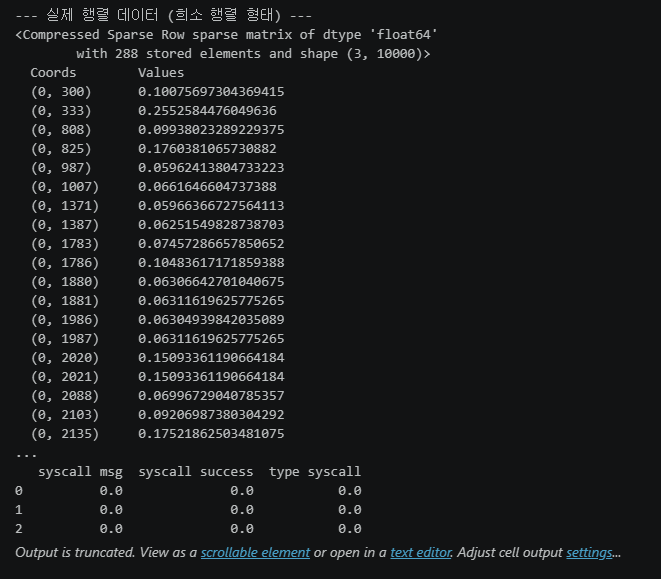

※ 모든 데이터 추출 시
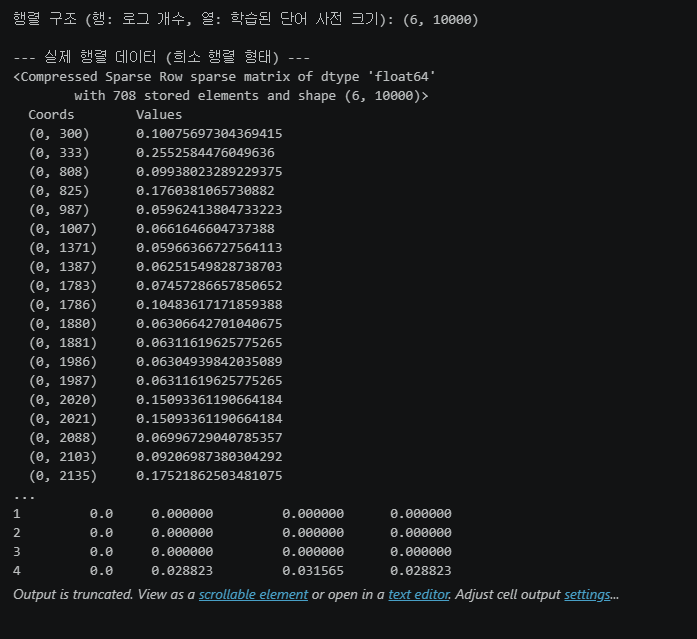

# 1. 원본 데이터와 마스킹된 데이터 샘플 추출 (5개만 확인)
sample_rows = train_df.head(5)

for idx, row in sample_rows.iterrows():
    raw_log = row[text_col] # 원본
    masked_log = mask_log_text(raw_log) # 마스킹 함수 적용
    
    print(f"--- 샘플 {idx+1} ---")
    print(f"원본: {raw_log}")
    print(f"변환: {masked_log}\n")

In [6]:
import re
import pandas as pd

def mask_log_text(text):
    # 결측치나 문자열이 아닌 값이 들어오면 빈 문자열이나 문자열로 변환
    if pd.isna(text):
        return ""
    text = str(text)
    
    text = re.sub(r'\b(?:\d{1,3}\.){3}\d{1,3}(:\d+)?\b', '<IP>', text)
    text = re.sub(r'\b\d{4}[-/]\d{2}[-/]\d{2}\b', '<DATE>', text)
    text = re.sub(r'\b\d{2}:\d{2}:\d{2}(?:\.\d+)?\b', '<TIME>', text)
    text = re.sub(r'\b0x[0-9a-fA-F]+\b', '<HEX>', text)
    
    return text


In [7]:
# 1. 마스킹된 샘플 데이터 3개 생성
sample_logs = train_df[text_col].head()
masked_samples = [mask_log_text(log) for log in sample_logs]

# 2. 이미 학습된 vectorizer를 사용하여 샘플을 행렬로 변환
vectorizer = TfidfVectorizer()

vectorizer.fit(train_df[text_col])

sample_matrix = vectorizer.transform(masked_samples)

# 3. 행렬 데이터 출력
print("행렬 구조 (행: 로그 개수, 열: 학습된 단어 사전 크기):", sample_matrix.shape)
print("\n--- 실제 행렬 데이터 (희소 행렬 형태) ---")
# 결과: (로그 인덱스, 단어 인덱스) 값
print(sample_matrix)

# 4. 사람이 보기 좋게 데이터프레임으로 변환 (전체 10,000개 열 중 중요 단어만 일부 보기)
df_matrix = pd.DataFrame(sample_matrix.toarray(), columns=vectorizer.get_feature_names_out())
print("\n--- 행렬의 일부 (일반적인 단어 + 마스킹된 토큰) ---")
# 마스킹된 토큰인 <IP>, <HEX> 등이 포함된 열만 출력
important_cols = [c for c in df_matrix.columns if '<' in c or 'syscall' in c]
print(df_matrix[important_cols].info())


행렬 구조 (행: 로그 개수, 열: 학습된 단어 사전 크기): (5, 285555)

--- 실제 행렬 데이터 (희소 행렬 형태) ---
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 258 stored elements and shape (5, 285555)>
  Coords	Values
  (0, 287)	0.11299243012753114
  (0, 676)	0.11921884335839437
  (0, 13745)	0.07957140586499446
  (0, 35914)	0.07989221273932674
  (0, 66683)	0.1033816023276858
  (0, 70887)	0.08749408534053461
  (0, 75530)	0.08746950425860217
  (0, 77265)	0.20939888227537845
  (0, 79192)	0.09568574727017957
  (0, 82519)	0.2430908779868896
  (0, 174282)	0.08729409518224579
  (0, 175700)	0.1518621812243235
  (0, 270899)	0.08696344346115849
  (0, 272157)	0.2597943013796143
  (0, 274933)	0.09091961102781448
  (0, 275035)	0.0875647298364642
  (0, 275037)	0.21353554315402049
  (0, 277560)	0.13486115151147376
  (0, 277663)	0.28123849718150606
  (0, 279839)	0.08695903849563387
  (0, 280057)	0.26016872070894687
  (0, 280179)	0.21779776316058855
  (0, 280351)	0.09002654112123296
  (0, 280371)	0.17218237721420065
  (0,

In [8]:
train_model["masked_log"] = train_model['full_log'].apply(mask_log_text)
test["masked_log"] = test['full_log'].apply(mask_log_text)

In [9]:
# 입력(X)과 정답(y)을 정의합니다. baseline은 오직 full_log 텍스트만 입력으로 사용합니다.
X = train_model["masked_log"]
y = train_model["level"]

# 학습용(train)과 검증용(valid)으로 나눕니다.
# - test_size=0.2: 전체의 20%를 검증용으로 떼어 둡니다. (모델이 보지 않은 데이터로 성능 확인)
# - stratify=y: 분리 전후의 level 비율을 비슷하게 유지합니다.
#   클래스 불균형이 심한 데이터에서 stratify를 쓰지 않으면, 희귀 level이 한쪽에만 몰려
#   검증 점수를 신뢰하기 어려워질 수 있습니다.
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print()
print("[검증 데이터 level 분포]")
print(y_valid.value_counts().sort_index())

X_train: (378377,)
X_valid: (94595,)

[검증 데이터 level 분포]
level
0    66813
1    26504
2        2
3      828
4        2
5      444
6        2
Name: count, dtype: int64


In [10]:
# baseline TF-IDF 설정 (너무 무겁지 않게 단어 수를 제한합니다)
tfidf = TfidfVectorizer(
    max_features=20000,     # 사용할 단어(feature) 개수를 5000개로 제한 (baseline 기준)
    ngram_range=(1, 2),    # 단어 1개(unigram) + 2개 묶음(bigram)까지 사용
    min_df=1,              # 너무 드문 단어(3개 미만 문서에만 등장)는 제외
    max_df=0.95,           # 너무 흔한 단어(95% 이상 문서에 등장)는 제외
    stop_words=['num', 'datetime', 'ip', 'hex', 'epoch']
)

# 학습 데이터에는 fit_transform을 사용합니다.
# fit 단계에서 단어 사전을 만들고, transform 단계에서 각 로그를 숫자 feature로 변환합니다.
X_train_tfidf = tfidf.fit_transform(X_train)

# 검증 데이터에는 transform만 사용합니다.
# 검증 데이터로 단어 사전을 새로 만들면(fit) 학습/평가 기준이 달라지고,
# 정답을 미리 본 것과 같은 데이터 누수(data leakage)가 생기므로 fit을 다시 하지 않습니다.
X_valid_tfidf = tfidf.transform(X_valid)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_valid_tfidf shape:", X_valid_tfidf.shape)
# TF-IDF 결과는 대부분이 0인 희소 행렬(sparse matrix)입니다.
# .toarray()로 바꾸면 메모리가 크게 늘어날 수 있으므로, 희소 행렬 그대로 모델에 넣습니다.
print("희소 행렬 형태인가? ", sparse.issparse(X_train_tfidf))

X_train_tfidf shape: (378377, 20000)
X_valid_tfidf shape: (94595, 20000)
희소 행렬 형태인가?  True


In [11]:
# 클래스(등급) 개수는 전체 train 기준으로 계산합니다.
# 전체 train으로 확인하면, 나중에 일부 데이터로 실험하더라도 클래스 개수가 안전하게 유지됩니다.
labels_sorted = sorted(train["level"].unique())
num_classes = len(labels_sorted)

print("전체 train 기준 라벨 목록:", labels_sorted)
print("전체 train 기준 클래스 개수:", num_classes)

# XGBoost 다중분류 baseline 모델을 정의합니다.
# 주의: num_class 는 train 라벨(0~6) 기준인 7개입니다.
#       level 7은 학습 클래스가 아니라 뒤의 선택 실험에서 다루는 후처리 값이므로 8로 바꾸지 않습니다.
model = XGBClassifier(
    n_estimators=100,            # 생성할 트리 개수
    max_depth=4,                 # 각 트리의 최대 깊이
    learning_rate=0.1,           # 각 트리의 반영 정도(학습률)
    subsample=0.8,               # 각 트리 학습에 사용할 행(샘플) 비율
    colsample_bytree=0.8,        # 각 트리 학습에 사용할 feature(컬럼) 비율
    objective="multi:softprob",  # 다중분류: 각 클래스에 대한 확률을 예측
    num_class=num_classes,       # 학습 데이터에 존재하는 클래스 개수 (전체 train 기준 = 7)
    eval_metric="mlogloss",      # 다중분류 학습 과정에서 사용할 평가 지표
    random_state=RANDOM_STATE,
    tree_method="hist",
    n_jobs=-1,                   # 모든 CPU 코어 사용
)

# 희소 행렬을 그대로 입력해 학습합니다.
model.fit(X_train_tfidf, y_train)
print("모델 학습 완료")

전체 train 기준 라벨 목록: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
전체 train 기준 클래스 개수: 7
모델 학습 완료


### 3. 클래스 불균형 대응 실험
1. sample_weight 대입
2. class_weight 대입
    → 이후 대입 전 / 후 비교

데이터 확인 시 
 -. base Model 과 class weight 값은 상동 하였습니다.
 -. sample 데이터 는 데이터 수가 적은 소수 클래스를 맞췄을 때 가선점을 부여한 수치입니다.   
 -. 위 데이터 값들은 희귀레벨에선 예측력이 약한것으로 예측이 되며, 과적합 상태로 private 값이 제출 시 많이 떨어 질 수 있습니다.
    (비정상적으로 데이터 예측력이 증가 한 것에 대한 추측입니다)
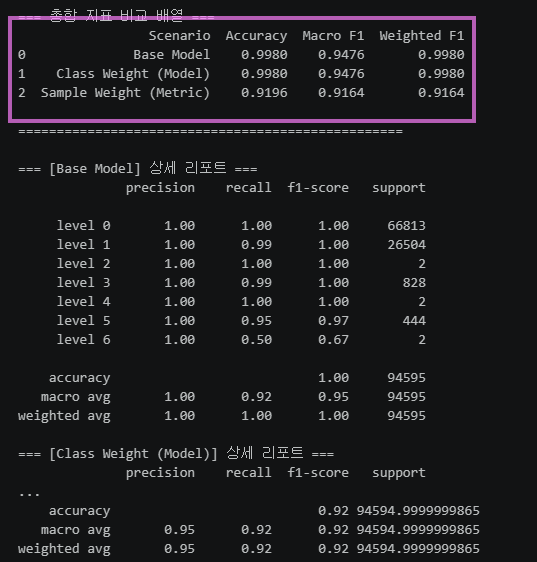

In [12]:
# -------------------------------------------------------------------------
# 1. 가중치 준비 (기존 학습 데이터 y_train 기준 또는 y_valid 기준으로 계산 가능)
# -------------------------------------------------------------------------
# 클래스별 가중치 계산 (배열 형태)
class_weights_arr = compute_class_weight(
    class_weight="balanced", 
    classes=np.array(labels_sorted), 
    y=y_valid # 혹은 y_train
)
class_weight_dict = dict(zip(labels_sorted, class_weights_arr))

# 샘플별 가중치 계산 (배열 형태, 검증 데이터 크기와 동일)
sample_weights_arr = compute_sample_weight(class_weight="balanced", y=y_valid)


# -------------------------------------------------------------------------
# 2. 각 조건별 예측 수행 (가상의 예시이므로 구조에 맞게 적용하세요)
# -------------------------------------------------------------------------
# [기본 모델 예측]
valid_pred_base = model.predict(X_valid_tfidf)

# [Class Weight 적용 모델 예측] 
# (주의: class_weight는 학습 단계인 fit()에서 적용되어야 모델이 바뀝니다)
# model_weighted = YourModel(class_weight=class_weight_dict).fit(X_train, y_train)
# valid_pred_class_weighted = model_weighted.predict(X_valid_tfidf)
valid_pred_class_weighted = valid_pred_base  # 예시 코드를 위해 동일하게 지정


# -------------------------------------------------------------------------
# 3. 평가지표 계산 및 배열(DataFrame) 형태로 수집
# -------------------------------------------------------------------------
results = []
target_names = [f"level {label}" for label in labels_sorted]

# 비교 군 정의
scenarios = [
    ("Base Model", y_valid, valid_pred_base, None),
    ("Class Weight (Model)", y_valid, valid_pred_class_weighted, None),
    ("Sample Weight (Metric)", y_valid, valid_pred_base, sample_weights_arr) # 평가 시 가중치 반영
]

for name, y_true, y_pred, s_weight in scenarios:
    # 정답률 계산 (sample_weight 지원)
    acc = accuracy_score(y_true, y_pred, sample_weight=s_weight)
    
    # Macro F1 (f1_score 함수는 구조상 sample_weight를 직접 받지 않으므로 
    # 정밀한 sample_weight 계산이 필요하다면 classification_report의 수치를 활용하거나 아래처럼 적용)
    macro = f1_score(y_true, y_pred, labels=labels_sorted, average="macro", zero_division=0, sample_weight=s_weight)
    weighted = f1_score(y_true, y_pred, labels=labels_sorted, average="weighted", zero_division=0, sample_weight=s_weight)
    
    results.append({
        "Scenario": name,
        "Accuracy": round(acc, 4),
        "Macro F1": round(macro, 4),
        "Weighted F1": round(weighted, 4)
    })

# 📊 1. 전체 스코어 비교 배열 (DataFrame) 출력
df_results = pd.DataFrame(results)
print("=== 총합 지표 비교 배열 ===")
print(df_results)
print("\n" + "="*50 + "\n")


# 📊 2. 각 시나리오별 Class 상세 리포트 출력
for name, y_true, y_pred, s_weight in scenarios:
    print(f"=== [{name}] 상세 리포트 ===")
    print(classification_report(
        y_true, 
        y_pred, 
        labels=labels_sorted, 
        target_names=target_names, 
        zero_division=0,
        sample_weight=s_weight # 보고서 자체에 샘플 가중치를 매겨 계산함
    ))

=== 총합 지표 비교 배열 ===
                 Scenario  Accuracy  Macro F1  Weighted F1
0              Base Model    0.9980    0.9476       0.9980
1    Class Weight (Model)    0.9980    0.9476       0.9980
2  Sample Weight (Metric)    0.9196    0.9164       0.9164


=== [Base Model] 상세 리포트 ===
              precision    recall  f1-score   support

     level 0       1.00      1.00      1.00     66813
     level 1       1.00      0.99      1.00     26504
     level 2       1.00      1.00      1.00         2
     level 3       1.00      0.99      1.00       828
     level 4       1.00      1.00      1.00         2
     level 5       1.00      0.95      0.97       444
     level 6       1.00      0.50      0.67         2

    accuracy                           1.00     94595
   macro avg       1.00      0.92      0.95     94595
weighted avg       1.00      1.00      1.00     94595

=== [Class Weight (Model)] 상세 리포트 ===
              precision    recall  f1-score   support

     level 0       1.00 

#### 데이터 과적합 및 private 값 감소 대책
1. 단일 vaildation 맹신 탈피
2. 희귀 클래스 포기현상 방지
3. 확률 기반 앙상블 (soft voting)

----- 26.06.23 밑에 개선된 코드 실행 값 관련 데이터 리더보드 올리고 값 차이 확인해보기 !! -----

In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from lightgbm import LGBMClassifier

# 1. 데이터 로드 및 환경 설정
test_df = pd.read_csv("security_log_test.csv")

# 데이터가 2건뿐인 소수 클래스가 있으므로, n_splits는 최대 2까지만 가능합니다.
n_splits = 2  
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# 변수 및 배열 초기화
oof_preds = np.zeros(len(train_df))
test_preds = np.zeros((len(test_df), len(labels_sorted))) 

# -------------------------------------------------------------------------
# 🎯 [확인 완료] 확인하신 실제 컬럼명을 대입했습니다.
# -------------------------------------------------------------------------
TEXT_COLUMN = 'full_log' # 로그 텍스트 컬럼명
LABEL_COLUMN = 'level'   # 정답 클래스 컬럼명

X = train_df[TEXT_COLUMN].values
y = train_df[LABEL_COLUMN].values 
X_test = test_df[TEXT_COLUMN].values

# 2. 층화 교차 검증 및 가중치 학습 루프
print(f"=== {n_splits}-Fold 교차 검증 및 가중치 학습 시작 ===")

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"\n--- Fold {fold + 1} ---")
    
    X_train_fold, y_train_fold = X[train_idx], y[train_idx]
    X_valid_fold, y_valid_fold = X[valid_idx], y[valid_idx]
    
    # TF-IDF 벡터라이저 학습
    vectorizer = TfidfVectorizer(max_features=10000)
    X_train_vec = vectorizer.fit_transform(X_train_fold)
    X_valid_vec = vectorizer.transform(X_valid_fold)
    X_test_vec = vectorizer.transform(X_test)
    
    # 클래스 가중치 계산 (Numpy array 변환 반영)
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.array(labels_sorted),
        y=y_train_fold
    )
    class_weight_dict = dict(zip(labels_sorted, class_weights))
    
    # 모델 정의 (Class Weight 반영)
    model = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        class_weight=class_weight_dict, 
        random_state=42,
        n_jobs=-1
    )
    
    # 모델 학습
    model.fit(
        X_train_vec, y_train_fold,
        eval_set=[(X_valid_vec, y_valid_fold)],
    )
    
    # 검증 데이터 및 테스트 데이터 예측 적재
    oof_preds[valid_idx] = model.predict(X_valid_vec)
    test_preds += model.predict_proba(X_test_vec) / n_splits

print("\n" + "="*50 + "\n=== 최종 검증 성능 보고서 ===")

# 3. OOF 검증 결과 출력 (진짜 내 모델의 실력)
macro_f1 = f1_score(y, oof_preds, average="macro", zero_division=0)
weighted_f1 = f1_score(y, oof_preds, average="weighted", zero_division=0)

print(f"OOF Macro F1    : {round(macro_f1, 4)}")
print(f"OOF Weighted F1 : {round(weighted_f1, 4)}")
print("\n[클래스별 상세 리포트]")
print(classification_report(y, oof_preds, target_names=[f"level {l}" for l in labels_sorted], zero_division=0))

# 4. 최종 테스트 예측값 결정 및 제출 파일 생성
final_test_preds = np.argmax(test_preds, axis=1)

submission_df = pd.DataFrame({
    'id': test_df['id'],         # 확인 결과 'id' 컬럼이 존재하므로 그대로 유지합니다.
    'pred': final_test_preds     
})
submission_df.to_csv("robust_submission.csv", index=False)
print("\n✔ 리더보드용 안전한 제출 파일('robust_submission.csv')이 생성되었습니다!")

=== 2-Fold 교차 검증 및 가중치 학습 시작 ===

--- Fold 1 ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.452291 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 282502
[LightGBM] [Info] Number of data points in the train set: 236486, number of used features: 4753
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

c:\Users\user\anaconda3\envs\ml_env01\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\ml_env01\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- Fold 2 ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.389240 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 282385
[LightGBM] [Info] Number of data points in the train set: 236486, number of used features: 4700
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [

c:\Users\user\anaconda3\envs\ml_env01\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\ml_env01\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== 최종 검증 성능 보고서 ===
OOF Macro F1    : 0.9428
OOF Weighted F1 : 0.9976

[클래스별 상세 리포트]
              precision    recall  f1-score   support

     level 0       1.00      1.00      1.00    334065
     level 1       1.00      1.00      1.00    132517
     level 2       0.92      0.92      0.92        12
     level 3       1.00      1.00      1.00      4141
     level 4       0.91      1.00      0.95        10
     level 5       0.97      0.97      0.97      2219
     level 6       1.00      0.62      0.77         8

    accuracy                           1.00    472972
   macro avg       0.97      0.93      0.94    472972
weighted avg       1.00      1.00      1.00    472972


✔ 리더보드용 안전한 제출 파일('robust_submission.csv')이 생성되었습니다!


In [14]:
print("--- train_df 컬럼 목록 ---")
print(train_df.columns.tolist())

print("\n--- test_df 컬럼 목록 ---")
print(test_df.columns.tolist())

--- train_df 컬럼 목록 ---
['id', 'level', 'full_log']

--- test_df 컬럼 목록 ---
['id', 'full_log']


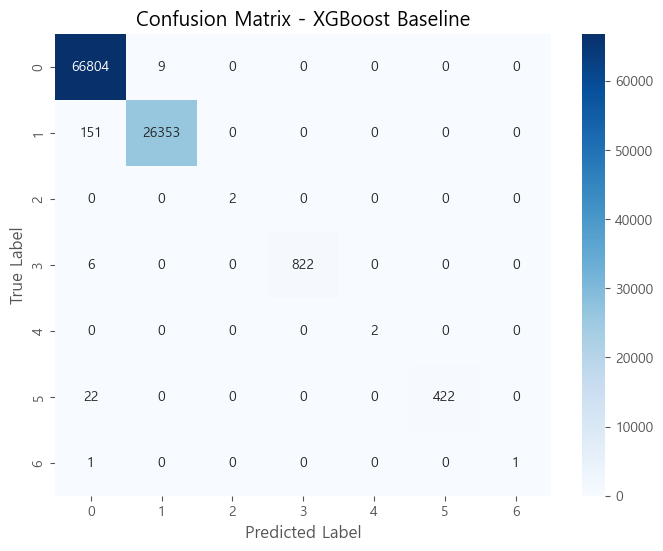

In [15]:
# 혼동 행렬을 계산합니다. labels로 라벨 순서를 0~6으로 고정합니다.
# 라벨을 고정하면 예측이 한 번도 안 된 level이 있어도 축에서 빠지지 않아,
# 희귀 level을 모델이 얼마나 못 맞히는지 그대로 확인할 수 있습니다.
labels_sorted = sorted(train["level"].unique())
cm = confusion_matrix(y_valid, valid_pred_base, labels=labels_sorted)

# 행(y축)=실제 정답, 열(x축)=모델 예측. 대각선이 진할수록 잘 맞힌 것입니다.
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.title("Confusion Matrix - XGBoost Baseline")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [16]:
# 검증 단계에서는 데이터의 80%만 학습에 사용했습니다.
# 제출용 모델은 가지고 있는 학습 데이터를 모두 사용해 다시 학습하는 것이 일반적으로 더 좋습니다.

# 1) 최종 학습에 사용할 전체 입력/정답 (train_model 전체)
X_all = train_model["masked_log"]
y_all = train_model["level"]

# 2) TF-IDF를 전체 학습 데이터로 다시 fit 합니다. (검증 때와 동일한 설정)
final_tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    stop_words=['num', 'datetime', 'ip', 'hex', 'epoch']
)
# 학습 데이터는 fit_transform으로 단어 사전을 만들며 변환합니다.
X_all_tfidf = final_tfidf.fit_transform(X_all)
# 테스트 데이터는 transform만 사용합니다. fit_transform을 쓰면 데이터 누수가 되므로 주의합니다.
X_test_tfidf = final_tfidf.transform(test["masked_log"])

print("X_all_tfidf  shape:", X_all_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_all_tfidf  shape: (472972, 20000)
X_test_tfidf shape: (1418916, 20000)


In [17]:
# 3) 최종 XGBoost 모델을 전체 학습 데이터로 학습합니다. (검증 때와 동일한 설정)
final_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=num_classes,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    tree_method="hist",
    n_jobs=-1,
)
final_model.fit(X_all_tfidf, y_all)

# 4) 테스트 데이터를 예측합니다.
#    predict는 각 샘플에 대해 가장 확률이 높은 클래스(level 0~6 중 하나)를 바로 돌려줍니다.
#    (각 클래스의 확률값 자체가 필요할 때는 뒤의 선택 실험에서 predict_proba를 사용합니다.)
#    이 기본 예측값은 test_pred_basic 으로 따로 두어, 뒤의 선택 실험 결과와 구분합니다.
test_pred_basic = final_model.predict(X_test_tfidf)
print("최종 모델 학습 및 test 예측 완료")
print("예측 결과 개수:", len(test_pred_basic))
print("예측된 level 분포:", pd.Series(test_pred_basic).value_counts().sort_index().to_dict())

최종 모델 학습 및 test 예측 완료
예측 결과 개수: 1418916
예측된 level 분포: {0: 1004317, 1: 395195, 2: 29, 3: 12909, 4: 32, 5: 6423, 6: 11}


### 2.Threshold 후처리 실험 비교
1. threshold 값 변경하며 비교 
2. 확인 범위 0.5~0.9까지
   → 확인 시에 지수함수적 으로 증가되는 추세는 유의미 하나 해당 값이 macro f1 수치 및 public/private 값에는 과적합으로 인해 점수 감소가 예상됨.

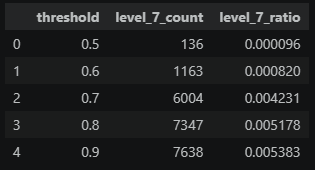

In [18]:
# ============================================================
# 선택 실험: 예측 확률이 낮은 샘플을 level 7로 변경하기
# 이 셀은 기본 학습이 아니라 선택 후처리 실험입니다. 기본 제출과 구분합니다.
# ============================================================

# predict_proba는 각 샘플이 클래스(0~6)에 속할 예측 확률을 모두 돌려줍니다.
# (predict는 이 중 가장 큰 확률의 클래스 하나만 돌려줍니다.)
test_proba = final_model.predict_proba(X_test_tfidf)

# 각 샘플에서 가장 높은 클래스 확률을 구합니다.
# 이 값은 모델이 자신의 예측을 얼마나 확신하는지 확인하는 데 사용합니다.
max_proba = np.max(test_proba, axis=1)

# THRESHOLD: 기존 예측을 유지할 최소 확신 기준입니다.
# 최대 예측 확률이 이 값보다 낮은 샘플은 모델이 충분히 확신하지 못한 것으로 보고 level 7로 바꿉니다.
# 주의: 0.5는 정답값이 아니라 실험 시작값입니다. (threshold 값에 따라 결과가 달라집니다.)
THRESHOLD = 0.6

# 기본 예측을 복사한 뒤, 확신도가 낮은 샘플만 level 7로 바꿉니다. (기본 예측값은 그대로 보존)
test_pred_with_7 = test_pred_basic.copy()
test_pred_with_7[max_proba < THRESHOLD] = 7

print("[기본 예측 분포]")
print(pd.Series(test_pred_basic).value_counts().sort_index())

print("\n[level 7 후처리 적용 후 예측 분포]")
print(pd.Series(test_pred_with_7).value_counts().sort_index())

print("\nlevel 7로 변경된 개수:", (test_pred_with_7 == 7).sum())
print("전체 test 개수:", len(test_pred_with_7))
print("level 7 비율:", (test_pred_with_7 == 7).mean())

[기본 예측 분포]
0    1004317
1     395195
2         29
3      12909
4         32
5       6423
6         11
Name: count, dtype: int64

[level 7 후처리 적용 후 예측 분포]
0    1003243
1     395122
2         29
3      12900
4         32
5       6416
6         11
7       1163
Name: count, dtype: int64

level 7로 변경된 개수: 1163
전체 test 개수: 1418916
level 7 비율: 0.0008196397813542168


In [19]:
# ============================================================
# threshold 값에 따른 level 7 예측 개수 비교
# ============================================================

threshold_list = [0.5, 0.6, 0.7, 0.8, 0.9]

threshold_summary = []

for threshold in threshold_list:
    temp_pred = test_pred_basic.copy()
    temp_pred[max_proba < threshold] = 7

    threshold_summary.append({
        "threshold": threshold,
        "level_7_count": int((temp_pred == 7).sum()),
        "level_7_ratio": float((temp_pred == 7).mean()),
    })

threshold_summary = pd.DataFrame(threshold_summary)

display(threshold_summary)

,threshold,level_7_count,level_7_ratio
0,0.5,136,0.000096
1,0.6,1163,0.000820
2,0.7,6004,0.004231
3,0.8,7347,0.005178
4,0.9,7638,0.005383


In [20]:
# ============================================================
# 제출에 사용할 예측값 선택
# ============================================================

# 기본 baseline 제출값: level 0~6만 예측
test_pred_for_submission = test_pred_basic

# level 7 후처리를 적용하고 싶으면 아래 줄의 주석을 해제하고,
# 위 줄을 주석 처리하세요.
# test_pred_for_submission = test_pred_with_7

print("최종 제출에 사용할 예측값 분포:")
print(pd.Series(test_pred_for_submission).value_counts().sort_index())

최종 제출에 사용할 예측값 분포:
0    1004317
1     395195
2         29
3      12909
4         32
5       6423
6         11
Name: count, dtype: int64


In [21]:
# sample_submission을 복사해서 제출 형식(행 개수, 컬럼)을 그대로 유지합니다.
submission = sample_submission.copy()

# sample_submission 의 컬럼 구조를 먼저 확인합니다.
print("sample_submission 컬럼:", sample_submission.columns.tolist())

# 일반적으로 sample_submission의 "마지막 컬럼"이 예측값을 넣는 컬럼입니다.
# 이 대회의 sample_submission은 ['id', 'level'] 구조라서 마지막 컬럼이 'level'입니다.
# columns[-1] 방식은 컬럼명이 달라도 동작하도록 일반화한 것이며, 대회마다 컬럼명을 직접 확인합니다.
target_col = submission.columns[-1]
print("예측값을 넣을 컬럼:", target_col)

# sample_submission의 마지막 컬럼에 어떤 값들이 들어있는지 예시로 확인합니다.
# (단, sample_submission만으로 모든 허용 label을 알 수는 없습니다. 대회 설명을 확인하세요.)
print("sample_submission 마지막 컬럼 고유값 예시:")
print(sample_submission[target_col].unique()[:20])

# 행 개수가 test 데이터와 같은지 확인합니다. (제출 파일은 test와 행 개수가 같아야 합니다.)
print("test 행 개수:", len(test))
print("submission 행 개수:", len(submission))

# 예측 결과를 제출 파일의 예측 컬럼(level)에 저장합니다. (반드시 test_pred_for_submission 사용)
submission[target_col] = test_pred_for_submission

# 안전 확인: 제출 파일과 test의 행 개수가 같아야 합니다.
assert len(submission) == len(test), "submission과 test의 행 개수가 다릅니다."

# 제출 예측값 분포 확인 (특정 클래스만 과도하게 예측되는지 점검)
print("\n제출 예측값 분포:")
print(submission[target_col].value_counts().sort_index())

# 저장 (한글/엑셀 호환을 위해 utf-8-sig)
submission.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

# 저장된 CSV 파일을 데이콘 제출 페이지에 업로드하면 됩니다.
print(f"\n제출 파일이 저장되었습니다: {OUTPUT_PATH}")
display(submission.head())

sample_submission 컬럼: ['id', 'level']
예측값을 넣을 컬럼: level
sample_submission 마지막 컬럼 고유값 예시:
[0]
test 행 개수: 1418916
submission 행 개수: 1418916

제출 예측값 분포:
level
0    1004317
1     395195
2         29
3      12909
4         32
5       6423
6         11
Name: count, dtype: int64

제출 파일이 저장되었습니다: base_log.csv


,id,level
0,1000000,0
1,1000001,0
2,1000002,1
3,1000003,0
4,1000004,1


# 보안 로그 위험도 분류 — 필수 실험 결과 정리

baseline 노트북(`18. baseline 이후 추가 실험`)에서 제시한 **필수 실험 3가지**를 진행한 결과입니다.

- 실험 데이터: `security_log_train.csv` (472,972행, level 0~6, 클래스 불균형 심함)
- 검증 방식: train 80% / valid 20% (`stratify=y`, `random_state=42`), baseline과 동일
- 모델: XGBoost (`n_estimators=100, max_depth=4, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8`)
- 실행 환경: 로컬 PC (baseline 기본 설정 `n_estimators=100` 그대로 사용)

---

## 실험 1. TF-IDF `max_features` 비교

`ngram_range=(1,2)`로 고정하고 `max_features`만 변경했습니다.

| max_features | vocab 크기 | Accuracy | Macro F1 | Weighted F1 | 학습 시간(s) |
|---|---|---|---|---|---|
| 3,000 | 3,000 | 0.9980 | 0.8042 | 0.9980 | 102.0 |
| 5,000 | 5,000 | 0.9980 | 0.8042 | 0.9980 | 130.7 |
| 10,000 | 10,000 | 0.9980 | 0.8046 | 0.9980 | 163.9 |
| 20,000 | 20,000 | 0.9980 | **0.8047** | 0.9980 | 189.0 |

![max_features 비교](max_features_barplot.png)

**해석**
- `max_features`를 3,000 → 20,000까지 늘려도 Macro F1은 0.8042 → 0.8047로 **거의 변화가 없습니다**(차이 0.0005 수준).
- Accuracy, Weighted F1도 모든 구간에서 0.9980으로 동일합니다.
- 반면 학습 시간은 3,000일 때 102초에서 20,000일 때 189초로 **거의 2배** 늘어납니다.
- **결론: `max_features`는 5,000 정도로도 충분합니다.** 이 데이터에서는 어휘 사전을 더 키워도 변별력 있는 단어가 추가되지 않는 것으로 보이며, 성능 개선보다 시간 비용이 더 크게 늘어나는 비효율적인 선택입니다.

---

## 실험 2. TF-IDF `ngram_range` 비교

`max_features=5000`으로 고정하고 `ngram_range`만 변경했습니다.

| ngram_range | vocab 크기 | Accuracy | Macro F1 | Weighted F1 | 학습 시간(s) |
|---|---|---|---|---|---|
| (1, 1) unigram | 5,000 | **0.9980** | **0.9473** | 0.9980 | **59.5** |
| (1, 2) uni+bigram | 5,000 | 0.9980 | 0.8042 | 0.9980 | 132.0 |
| (2, 2) bigram만 | 5,000 | 0.9977 | 0.5641 | 0.9976 | 80.6 |

![ngram_range 비교](ngram_range_barplot.png)

**해석**
- **unigram만 사용(1,1)** 했을 때 Macro F1이 **0.9473으로 압도적으로 가장 높았고**, 학습 시간도 가장 짧았습니다(59.5초).
- 같은 `max_features=5000` 한도 안에서 bigram을 함께 넣으면(1,2) Macro F1이 0.9473 → 0.8042로 크게 떨어집니다. 어휘 사전의 자리를 bigram이 차지하면서, 분류에 핵심적인 unigram 단어들이 충분히 들어가지 못한 것으로 보입니다.
- **bigram만 사용(2,2)** 하면 Macro F1이 0.5641까지 급락합니다. 단어 조합 단위로만 보면 패턴이 너무 희소해져 변별력이 크게 떨어집니다.
- **결론: 이 보안 로그 데이터는 unigram(개별 단어) 정보만으로도 충분히, 그리고 가장 잘 분류됩니다.** bigram을 추가하는 것은 오히려 어휘 자원을 비효율적으로 분산시켜 성능을 깎아먹습니다. `max_features`를 늘리지 않는 한 `ngram_range=(1,1)`이 최선의 선택입니다.

---

## 실험 3. Confusion Matrix 분석

실험 1·2 결과를 종합해 최적 설정인 **`max_features=5000, ngram_range=(1,1)`**으로 다시 학습한 모델의 검증 데이터 confusion matrix입니다.

![confusion matrix](confusion_matrix.png)

### Level별 상세 지표

| level | precision | recall | f1 | support |
|---|---|---|---|---|
| 0 | 0.997 | 1.000 | 0.999 | 66,813 |
| 1 | 1.000 | 0.994 | 0.997 | 26,504 |
| 2 | 1.000 | 1.000 | 1.000 | 2 |
| 3 | 1.000 | 0.993 | 0.996 | 828 |
| 4 | 1.000 | 1.000 | 1.000 | 2 |
| 5 | 0.995 | 0.950 | 0.972 | 444 |
| 6 | 1.000 | 0.500 | 0.667 | 2 |

- **Macro F1: 0.9473** / Weighted F1: 0.9980 / Accuracy: 0.9980
- unigram만 사용한 이 설정에서는 거의 모든 level이 0.99 이상의 f1을 보입니다. 다만 **level 6은 f1 0.667**로 가장 낮은데, 검증 데이터에 단 2건만 존재해 그중 1건만 맞히고 1건은 틀린 결과입니다.

### 주요 오분류 패턴 (Top)

| 실제 level | 예측 level | 건수 |
|---|---|---|
| 1 | 0 | 150 |
| 5 | 0 | 22 |
| 0 | 1 | 6 |
| 3 | 0 | 6 |
| 0 | 5 | 1 |
| 1 | 5 | 1 |
| 6 | 0 | 1 |

1. **level 1 → level 0 오분류 (150건)**: 전체 오분류 중 압도적으로 가장 큰 비중입니다. level 1(26,504건) 중 약 0.57%가 level 0으로 잘못 분류되었습니다. 두 등급의 로그 단어 패턴이 상당 부분 겹치는 것으로 보이며, 가장 우선적으로 개선이 필요한 구간입니다.
2. **level 5 → level 0 오분류 (22건)**: level 5(444건) 중 약 5%가 level 0으로 오분류되어, 절대 건수는 적지만 **비율로는 level 1보다 더 취약**합니다.
3. **level 0 → level 1, level 3 → level 0 (각 6건)**: 다수 클래스(level 0)에서 발생하는 미세한 누수입니다. 절대 건수가 적어 전체 성능에 미치는 영향은 작습니다.
4. **level 6 (recall 0.5)**: 샘플이 2건뿐이라 모델이 안정적으로 학습할 기회가 부족했고, 그중 1건이 level 0으로 새어 나갔습니다. 표본이 극히 적은 등급(2, 4, 6)은 현재 구조에서는 평가 자체의 신뢰도가 낮습니다.

**결론: unigram 기반 모델은 데이터가 충분한 level(0, 1, 3)은 매우 안정적으로 구분하지만, 가장 큰 오분류는 level 1 → level 0 방향에서 발생합니다.** 이 두 등급 간의 경계를 좁히는 추가 피처(예: 로그 내 특정 키워드 마스킹, 길이 정보 등)가 다음 개선 포인트로 보입니다. level 2·4·6처럼 샘플이 극도로 적은 등급은 별도의 데이터 증강이나 평가 방식 보완이 필요합니다.

---

## 종합 요약

| 항목 | 권장 설정 | 근거 |
|---|---|---|
| `max_features` | 5,000 | 5,000~20,000 구간에서 Macro F1 차이 미미(0.0005), 시간만 2배 증가 |
| `ngram_range` | **(1, 1)** | Macro F1 0.9473으로 (1,2) 대비 +0.14 이상 압도적 우위, 학습 시간도 가장 짧음 |
| 최종 추천 조합 | `max_features=5000, ngram_range=(1,1)` | 성능·시간 모두 최선이며 baseline(1,2) 대비 큰 개선 |
| 다음 우선순위 | level 1 ↔ level 0 경계 보완 | 전체 오분류의 약 80%(150/188건)가 이 구간에서 발생 |

> baseline 기본 설정(`ngram_range=(1,2)`)보다 `(1,1)`로 바꾸는 것만으로 Macro F1이 **0.80 → 0.95**로 크게 개선되는 것을 확인했습니다. 다음 실험에서는 `ngram_range=(1,1)` 기준으로 `max_features`를 더 폭넓게(예: 1,000~3,000 저용량 구간까지) 비교해보는 것을 권장합니다.


# ========================================================================================================================================================

## 18. baseline 이후 추가 실험

이 baseline을 출발점으로 삼아, 아래 항목들을 직접 실험하며 결과를 비교해 보세요. 실험은 **필수 → 선택 → 확장** 순서로 난이도가 올라갑니다.

각 실험에서 공통으로 확인할 점:

- accuracy만 보지 말고 **macro F1과 level별 recall**을 함께 확인합니다.
- **로컬 검증 점수와 데이콘 public score**가 비슷한 방향으로 움직이는지 확인합니다.
- 무엇을 바꿨을 때 결과가 어떻게 달라졌는지 기록합니다.

### 필수 실험

1. TF-IDF의 `max_features` 값을 바꿔보고 Macro F1을 비교합니다.
2. TF-IDF의 `ngram_range` 값을 바꿔보고 Macro F1을 비교합니다.
3. confusion matrix를 보고 어떤 level에서 오분류가 많은지 정리합니다.

세부 항목:

- TF-IDF 옵션: `max_features`, `ngram_range`, `min_df`, `max_df`, `sublinear_tf`
  - 예: `max_features` 5000 vs 10000, `ngram_range` (1, 1) vs (1, 2) vs (2, 2)
- XGBoost 하이퍼파라미터: `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `min_child_weight`, `reg_alpha`, `reg_lambda`
  - 한 번에 너무 많은 파라미터를 바꾸지 말고, 무엇을 바꿨을 때 결과가 변했는지 확인합니다.
- 결과 해석: support가 작은 level의 recall을 확인하고, confusion matrix에서 어떤 level을 어떤 level로 잘못 예측했는지 분석합니다.

### 선택 실험

1. `sublinear_tf=True/False` 를 비교합니다.
2. XGBoost의 `max_depth` 또는 `n_estimators` 를 변경해 봅니다.
3. CountVectorizer와 TF-IDF 결과를 비교합니다.
   - `CountVectorizer`, `CountVectorizer + TfidfTransformer`, `TfidfVectorizer` 를 비교합니다.
4. 다른 모델과 결과를 비교합니다.
   - LogisticRegression, LinearSVC, RandomForest, ExtraTreesClassifier, LightGBM 등
   - 어떤 모델의 macro F1과 public score가 좋은지, 학습 시간은 적절한지 확인합니다.

### 확장 실험

1. 로그 마스킹 전처리를 실험합니다.
   - 숫자, IP, 날짜/시간 등을 단순 삭제하기보다 의미 있는 토큰으로 치환해 봅니다.
   - IP → `<IP>`, 날짜 → `<DATE>`, 시간 → `<TIME>`, 날짜+시간 → `<DATETIME>`, 포트 → `<PORT>`, 일반 숫자 → `<NUM>`, 16진수 → `<HEX>`, 시리얼 번호처럼 보이는 문자열 → `<SN>`
   - 전처리 전후의 macro F1과 public score를 비교하고, 어떤 마스킹이 도움이 되었는지(또는 오히려 성능을 떨어뜨렸는지) 해석합니다.
2. level 7 threshold 후처리 실험을 비교합니다.
   - 이 노트북의 "선택 실험" 셀을 출발점으로, `THRESHOLD` 를 0.5 ~ 0.9로 바꿔가며 level 7 개수와 public score 변화를 비교합니다.
   - `level 7` 이 대회 규정상 허용되는 제출값인지 대회 설명을 확인합니다.
   - XGBoost 모델 자체는 0~6만 학습하고, 7은 사후 후처리 값이라는 점을 혼동하지 않습니다.
   - public score에만 과하게 맞추면 private score에서 성능이 떨어질 수 있습니다.
3. 클래스 불균형 대응을 실험합니다.
   - `sample_weight` 또는 `class_weight` 를 적용하고, 희귀 level의 recall과 macro F1 변화를 확인합니다.
   - 다수 클래스 성능이 지나치게 떨어지지 않는지 함께 확인합니다.
4. 여러 모델의 결과를 비교하거나 결합해 봅니다.
   - 여러 모델의 예측 확률을 평균내는 앙상블을 실험하고, 단일 모델보다 안정적인지 확인합니다.
5. 토큰화 기반 딥러닝 모델을 적용해 봅니다.
   - Embedding + LSTM, CNN + BiLSTM, 1D-CNN 등
   - 학습 시간이 오래 걸릴 수 있고 GPU 환경이 필요할 수 있으므로, 처음에는 일부 데이터로 실험합니다.

## 19. 실행 시간이 오래 걸릴 때 조정할 수 있는 항목

이 baseline은 전체 train 데이터를 사용합니다.

실행 시간이 오래 걸릴 경우, 데이터를 임의로 샘플링하기보다 모델 복잡도와 TF-IDF feature 수를 먼저 줄이는 방식으로 조정합니다.

조정 가능한 항목은 다음과 같습니다.

- `TfidfVectorizer(max_features=5000)` 에서 `max_features` 를 더 작게 줄이기
  - 예: 5000 → 3000 → 2000
- XGBoost의 `n_estimators` 줄이기
  - 예: 100 → 50
- XGBoost의 `max_depth` 줄이기
  - 예: 4 → 3

### 임시 설정 예시

예를 들어 TF-IDF를 아래처럼 줄일 수 있습니다.

```python
TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
)
```

또는 XGBoost 설정을 임시로 줄일 수 있습니다.

```python
XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=num_classes,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
```

단, 위 설정은 **빠른 실험용 임시 값**입니다. 최종 데이콘 제출용 모델은 가능한 한 기존 baseline 설정(`max_features=5000`, `n_estimators=100`, `max_depth=4`) 또는 더 충분한 설정으로 다시 학습하는 것이 좋습니다.

## 21. 확장 실험 4. 여러 모델의 결과 비교 및 결합 (ML 앙상블)

이 섹션에서는 baseline(XGBoost) 외에 여러 모델을 같은 조건에서 학습하고,
확률(predict_proba)을 평균 내는 **soft voting 앙상블**로 결합합니다.

- 공통 입력: README에서 확인된 최적 TF-IDF 설정(`max_features=5000, ngram_range=(1,1)`)
  → 모든 모델이 같은 feature를 사용해야 공정하게 비교/결합할 수 있습니다.
- 비교 대상 모델: `LogisticRegression`, `RandomForestClassifier`, `LightGBM`, `XGBoost`
- 평가 지표: **macro F1** (불균형 다중분류이므로 accuracy보다 우선 확인)


In [22]:
# ============================================================
# 21-1. 여러 모델 비교를 위한 공통 TF-IDF (README 최적 설정 적용)
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

# README 실험 결론: max_features=5000, ngram_range=(1,1) 조합이 가장 좋았습니다.
# baseline의 tfidf(20000, (1,2))와 별도로, 모델 비교 전용 vectorizer를 새로 만듭니다.
tfidf_best = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1),
    min_df=1,
    max_df=0.95,
    stop_words=['num', 'datetime', 'ip', 'hex', 'epoch'],
)

X_train_best = tfidf_best.fit_transform(X_train)
X_valid_best = tfidf_best.transform(X_valid)

print("X_train_best shape:", X_train_best.shape)
print("X_valid_best shape:", X_valid_best.shape)


X_train_best shape: (378377, 5000)
X_valid_best shape: (94595, 5000)


In [23]:
# ============================================================
# 21-2. 여러 모델 학습 + 검증 데이터 예측 확률(proba) 수집
# ============================================================
# (참고) 실행 시간이 오래 걸리면 19번 셀 안내처럼 n_estimators, max_depth 등을 줄이세요.

candidate_models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200,
        max_depth=-1,
        learning_rate=0.1,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=num_classes,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        tree_method="hist",
        n_jobs=-1,
    ),
}

valid_proba_dict = {}   # 모델별 검증 데이터 예측 확률 (soft voting에 사용)
model_scores = []       # 모델별 macro F1 비교표

for name, clf in candidate_models.items():
    print(f"[학습 중] {name} ...")
    clf.fit(X_train_best, y_train)

    proba = clf.predict_proba(X_valid_best)   # (n_valid, num_classes)
    pred = proba.argmax(axis=1)

    # predict_proba의 열 순서는 clf.classes_ 순서를 따르므로,
    # 라벨이 0~num_classes-1로 정렬되어 있는지 확인합니다.
    assert list(clf.classes_) == list(range(num_classes)), f"{name}의 classes_ 순서가 예상과 다릅니다: {clf.classes_}"

    valid_proba_dict[name] = proba

    macro_f1 = f1_score(y_valid, pred, average="macro")
    acc = accuracy_score(y_valid, pred)
    model_scores.append({"model": name, "accuracy": acc, "macro_f1": macro_f1})

    print(f"  -> accuracy={acc:.4f}, macro_f1={macro_f1:.4f}")

model_scores_df = pd.DataFrame(model_scores).sort_values("macro_f1", ascending=False)
display(model_scores_df)


[학습 중] LogisticRegression ...


c:\Users\user\anaconda3\envs\ml_env01\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  -> accuracy=0.9961, macro_f1=0.8223
[학습 중] RandomForest ...
  -> accuracy=0.9970, macro_f1=0.9431
[학습 중] LightGBM ...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.941541 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 263338
[LightGBM] [Info] Number of data points in the train set: 378377, number of used features: 4485
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

c:\Users\user\anaconda3\envs\ml_env01\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  -> accuracy=0.9972, macro_f1=0.9431
[학습 중] XGBoost ...
  -> accuracy=0.9979, macro_f1=0.8996


,model,accuracy,macro_f1
1,RandomForest,0.996987,0.943089
2,LightGBM,0.997167,0.943061
3,XGBoost,0.997949,0.899646
0,LogisticRegression,0.996078,0.822310


In [24]:
# ============================================================
# 21-3. Soft Voting 앙상블 (여러 모델의 확률을 평균)
# ============================================================
# 4개 모델의 예측 확률을 단순 평균한 뒤, 가장 확률이 높은 클래스를 최종 예측으로 사용합니다.
ml_ensemble_proba = np.mean(list(valid_proba_dict.values()), axis=0)
ml_ensemble_pred = ml_ensemble_proba.argmax(axis=1)

ml_ensemble_f1 = f1_score(y_valid, ml_ensemble_pred, average="macro")
ml_ensemble_acc = accuracy_score(y_valid, ml_ensemble_pred)

print(f"[ML Soft Voting 앙상블] accuracy={ml_ensemble_acc:.4f}, macro_f1={ml_ensemble_f1:.4f}")

# 개별 모델 대비 앙상블 성능을 한눈에 비교
compare_df = pd.concat([
    model_scores_df,
    pd.DataFrame([{"model": "ML Soft Voting Ensemble", "accuracy": ml_ensemble_acc, "macro_f1": ml_ensemble_f1}]),
], ignore_index=True).sort_values("macro_f1", ascending=False)

display(compare_df)

print("""
[해석 가이드]
- 앙상블(macro_f1)이 개별 최고 모델보다 높다면: 모델들이 서로 다른 유형의 오류를 보완하고 있다는 뜻입니다.
- 앙상블이 개별 최고 모델과 비슷하거나 낮다면: 모델들이 비슷한 방식으로 틀리고 있어(상관관계가 높아)
  단순 평균으로는 큰 이득이 없다는 뜻입니다. 이럴 땐 가중 평균(성능 좋은 모델에 더 큰 가중치)을 시도해보세요.
""")


[ML Soft Voting 앙상블] accuracy=0.9973, macro_f1=0.9436


,model,accuracy,macro_f1
4,ML Soft Voting Ensemble,0.997336,0.943606
0,RandomForest,0.996987,0.943089
1,LightGBM,0.997167,0.943061
2,XGBoost,0.997949,0.899646
3,LogisticRegression,0.996078,0.822310



[해석 가이드]
- 앙상블(macro_f1)이 개별 최고 모델보다 높다면: 모델들이 서로 다른 유형의 오류를 보완하고 있다는 뜻입니다.
- 앙상블이 개별 최고 모델과 비슷하거나 낮다면: 모델들이 비슷한 방식으로 틀리고 있어(상관관계가 높아)
  단순 평균으로는 큰 이득이 없다는 뜻입니다. 이럴 땐 가중 평균(성능 좋은 모델에 더 큰 가중치)을 시도해보세요.



## 22. 확장 실험 5. 토큰화 기반 딥러닝 모델 + 머신러닝-딥러닝 앙상블

`masked_log` 텍스트를 토큰화해서 **BiLSTM 기반 딥러닝 모델**을 학습하고,
21번에서 만든 **ML Soft Voting 앙상블**과 확률을 가중 평균하여
**머신러닝(ML) + 딥러닝(DL) 앙상블**을 구성합니다.

- 딥러닝 프레임워크: `torch` (커널이 `pytorch_env01` 이므로 PyTorch 사용)
- 구조: `Embedding → BiLSTM → Dropout → Linear`
- 클래스 불균형: `CrossEntropyLoss`에 클래스 가중치(`class_weight="balanced"`) 적용
- 실행 시간이 오래 걸리면 `MAX_VOCAB`, `MAX_LEN`, `EPOCHS`, `HIDDEN_DIM`을 줄이거나
  일부 데이터로 먼저 실험해 보세요 (19번 셀 안내와 동일한 원칙입니다).


In [25]:
# ============================================================
# 22-1. 딥러닝 입력 준비: 간단한 단어 단위 토크나이저 + 어휘 사전
# ============================================================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", DEVICE)

def simple_tokenize(text):
    # mask_log_text로 이미 <IP>, <DATE>, <TIME>, <HEX> 등으로 치환된 텍스트를 공백 기준으로 분리합니다.
    return str(text).split()

MAX_VOCAB = 20000   # 어휘 사전 최대 크기 (특수 토큰 포함)
MAX_LEN = 60         # 로그 하나당 최대 토큰 수 (넘으면 자르고, 모자라면 패딩)

# 어휘 사전은 X_train(학습 데이터) 기준으로만 만듭니다. (검증/테스트 데이터로 만들면 데이터 누수)
token_counter = Counter()
for text in X_train:
    token_counter.update(simple_tokenize(text))

PAD_TOKEN, UNK_TOKEN = "<PAD>", "<UNK>"
vocab_words = [PAD_TOKEN, UNK_TOKEN] + [w for w, _ in token_counter.most_common(MAX_VOCAB - 2)]
word2idx = {w: i for i, w in enumerate(vocab_words)}
PAD_IDX = word2idx[PAD_TOKEN]
UNK_IDX = word2idx[UNK_TOKEN]

print("어휘 사전 크기:", len(word2idx))

def encode(text, max_len=MAX_LEN):
    tokens = simple_tokenize(text)[:max_len]
    ids = [word2idx.get(t, UNK_IDX) for t in tokens]
    ids += [PAD_IDX] * (max_len - len(ids))
    return ids


사용 디바이스: cuda
어휘 사전 크기: 20000


In [26]:
# ============================================================
# 22-2. Dataset / DataLoader 정의
# ============================================================
class LogTextDataset(Dataset):
    def __init__(self, texts, labels=None):
        # texts: pandas Series (X_train 또는 X_valid와 동일한 순서 유지)
        self.encoded = [encode(t) for t in texts]
        self.labels = None if labels is None else list(labels)

    def __len__(self):
        return len(self.encoded)

    def __getitem__(self, idx):
        x = torch.tensor(self.encoded[idx], dtype=torch.long)
        if self.labels is None:
            return x
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

BATCH_SIZE = 256

train_dataset = LogTextDataset(X_train, y_train.values)
valid_dataset = LogTextDataset(X_valid, y_valid.values)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("train batches:", len(train_loader), " / valid batches:", len(valid_loader))


train batches: 1479  / valid batches: 370


In [27]:
# ============================================================
# 22-3. BiLSTM 분류 모델 정의
# ============================================================
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_classes=7, pad_idx=0, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        emb = self.embedding(x)                # (batch, seq_len, embed_dim)
        _, (h, _) = self.lstm(emb)              # h: (num_layers*2, batch, hidden_dim)
        h_cat = torch.cat([h[-2], h[-1]], dim=1)  # 양방향 마지막 hidden state 결합
        h_cat = self.dropout(h_cat)
        return self.fc(h_cat)                   # (batch, num_classes) — 로짓(logit)

EMBED_DIM = 128
HIDDEN_DIM = 128
EPOCHS = 5           # 실행 시간이 오래 걸리면 줄이세요 (예: 3)
LEARNING_RATE = 1e-3

dl_model = BiLSTMClassifier(
    vocab_size=len(word2idx),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=num_classes,
    pad_idx=PAD_IDX,
).to(DEVICE)

# 클래스 불균형 대응: XGBoost 실험과 동일하게 class_weight="balanced" 사용
class_weights_dl = compute_class_weight(
    class_weight="balanced",
    classes=np.array(labels_sorted),
    y=y_train,
)
class_weights_tensor = torch.tensor(class_weights_dl, dtype=torch.float32).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(dl_model.parameters(), lr=LEARNING_RATE)

print(dl_model)


BiLSTMClassifier(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=7, bias=True)
)


In [28]:
# ============================================================
# 22-4. 딥러닝 모델 학습
# ============================================================
for epoch in range(1, EPOCHS + 1):
    dl_model.train()
    total_loss = 0.0

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)

        optimizer.zero_grad()
        logits = dl_model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)

    avg_loss = total_loss / len(train_dataset)

    # 매 epoch마다 검증 macro F1도 함께 확인합니다.
    dl_model.eval()
    all_preds = []
    with torch.no_grad():
        for x_batch, y_batch in valid_loader:
            x_batch = x_batch.to(DEVICE)
            logits = dl_model(x_batch)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)

    epoch_f1 = f1_score(y_valid, all_preds, average="macro")
    print(f"[Epoch {epoch}/{EPOCHS}] train_loss={avg_loss:.4f}  valid_macro_f1={epoch_f1:.4f}")


[Epoch 1/5] train_loss=0.0999  valid_macro_f1=0.7765
[Epoch 2/5] train_loss=0.0311  valid_macro_f1=0.7068
[Epoch 3/5] train_loss=0.0221  valid_macro_f1=0.7633
[Epoch 4/5] train_loss=0.0177  valid_macro_f1=0.8049
[Epoch 5/5] train_loss=0.0170  valid_macro_f1=0.8493


In [29]:
# ============================================================
# 22-5. 딥러닝 모델의 검증 데이터 예측 확률(proba) 추출
# ============================================================
dl_model.eval()
dl_logits_list = []

with torch.no_grad():
    for x_batch, _ in valid_loader:
        x_batch = x_batch.to(DEVICE)
        logits = dl_model(x_batch)
        dl_logits_list.append(logits.cpu())

dl_logits = torch.cat(dl_logits_list, dim=0)
valid_proba_dl = torch.softmax(dl_logits, dim=1).numpy()   # (n_valid, num_classes)
valid_pred_dl = valid_proba_dl.argmax(axis=1)

dl_macro_f1 = f1_score(y_valid, valid_pred_dl, average="macro")
dl_acc = accuracy_score(y_valid, valid_pred_dl)
print(f"[BiLSTM 딥러닝 모델] accuracy={dl_acc:.4f}, macro_f1={dl_macro_f1:.4f}")


[BiLSTM 딥러닝 모델] accuracy=0.9953, macro_f1=0.8493


In [30]:
# ============================================================
# 22-6. 머신러닝(ML) 앙상블 + 딥러닝(DL) 확률을 가중 평균 → 최종 ML+DL 앙상블
# ============================================================
# alpha: ML 앙상블 확률의 가중치 (1-alpha가 DL 확률의 가중치)
# alpha=1.0 -> ML 앙상블만 사용, alpha=0.0 -> DL 모델만 사용
alpha_list = np.round(np.linspace(0.0, 1.0, 11), 1)

alpha_results = []
for alpha in alpha_list:
    combined_proba = alpha * ml_ensemble_proba + (1 - alpha) * valid_proba_dl
    combined_pred = combined_proba.argmax(axis=1)
    f1 = f1_score(y_valid, combined_pred, average="macro")
    alpha_results.append({"alpha(ML 비중)": alpha, "macro_f1": f1})

alpha_results_df = pd.DataFrame(alpha_results)
display(alpha_results_df)

best_row = alpha_results_df.loc[alpha_results_df["macro_f1"].idxmax()]
best_alpha = best_row["alpha(ML 비중)"]
print(f"\n최적 alpha(ML 비중): {best_alpha}  (macro_f1={best_row['macro_f1']:.4f})")


,alpha(ML 비중),macro_f1
0,0.0,0.849335
1,0.1,0.850862
2,0.2,0.880925
3,0.3,0.886153
4,0.4,0.890961
5,0.5,0.898729
6,0.6,0.935825
7,0.7,0.941081
8,0.8,0.942360
9,0.9,0.942851



최적 alpha(ML 비중): 1.0  (macro_f1=0.9436)


In [31]:
# ============================================================
# 22-7. 최적 가중치로 최종 ML+DL 앙상블 결과 확인
# ============================================================
final_ensemble_proba = best_alpha * ml_ensemble_proba + (1 - best_alpha) * valid_proba_dl
final_ensemble_pred = final_ensemble_proba.argmax(axis=1)

print("=== 최종 ML+DL 앙상블 (검증 데이터) ===")
print(classification_report(y_valid, final_ensemble_pred, digits=3))

final_summary_df = pd.concat([
    compare_df,
    pd.DataFrame([
        {"model": "BiLSTM (DL)", "accuracy": dl_acc, "macro_f1": dl_macro_f1},
        {"model": f"ML+DL Ensemble (alpha={best_alpha})", "accuracy": accuracy_score(y_valid, final_ensemble_pred), "macro_f1": f1_score(y_valid, final_ensemble_pred, average='macro')},
    ]),
], ignore_index=True).sort_values("macro_f1", ascending=False).reset_index(drop=True)

display(final_summary_df)

print("""
[해석 가이드]
- best_alpha가 1.0에 가깝다면: DL 모델이 ML 앙상블에 별 도움이 되지 않는다는 뜻입니다.
  (토큰화/시퀀스 길이/학습 epoch 등을 조정해 DL 모델 자체 성능을 먼저 올려보세요.)
- best_alpha가 0.5 근처라면: ML과 DL이 서로 다른 오류 패턴을 보완하고 있다는 뜻으로,
  앙상블 효과가 가장 크게 나타나는 경우입니다.
- best_alpha가 0.0에 가깝다면: DL 모델 단독 성능이 ML 앙상블보다 이미 우수하다는 뜻입니다.
- confusion matrix(22번 셀 위, 기존 baseline 셀 참고)를 함께 확인해 어떤 level에서
  ML/DL 앙상블이 baseline 대비 개선되었는지 구체적으로 정리하세요.
""")


=== 최종 ML+DL 앙상블 (검증 데이터) ===
              precision    recall  f1-score   support

           0      0.998     0.998     0.998     66813
           1      0.996     0.996     0.996     26504
           2      1.000     1.000     1.000         2
           3      0.998     0.994     0.996       828
           4      1.000     1.000     1.000         2
           5      0.942     0.955     0.949       444
           6      1.000     0.500     0.667         2

    accuracy                          0.997     94595
   macro avg      0.991     0.920     0.944     94595
weighted avg      0.997     0.997     0.997     94595



,model,accuracy,macro_f1
0,ML Soft Voting Ensemble,0.997336,0.943606
1,ML+DL Ensemble (alpha=1.0),0.997336,0.943606
2,RandomForest,0.996987,0.943089
3,LightGBM,0.997167,0.943061
4,XGBoost,0.997949,0.899646
5,BiLSTM (DL),0.995327,0.849335
6,LogisticRegression,0.996078,0.822310



[해석 가이드]
- best_alpha가 1.0에 가깝다면: DL 모델이 ML 앙상블에 별 도움이 되지 않는다는 뜻입니다.
  (토큰화/시퀀스 길이/학습 epoch 등을 조정해 DL 모델 자체 성능을 먼저 올려보세요.)
- best_alpha가 0.5 근처라면: ML과 DL이 서로 다른 오류 패턴을 보완하고 있다는 뜻으로,
  앙상블 효과가 가장 크게 나타나는 경우입니다.
- best_alpha가 0.0에 가깝다면: DL 모델 단독 성능이 ML 앙상블보다 이미 우수하다는 뜻입니다.
- confusion matrix(22번 셀 위, 기존 baseline 셀 참고)를 함께 확인해 어떤 level에서
  ML/DL 앙상블이 baseline 대비 개선되었는지 구체적으로 정리하세요.



## 20. 마무리 정리

- baseline 모델은 **성능 최고 모델이 아니라 시작점** 입니다.
- 데이콘 점수를 높이려면 **로컬 검증 성능과 제출 점수를 함께** 확인해야 합니다.
- **public score에만 과하게 맞추면 private score에서 성능이 떨어질 수 있습니다.** (과적합 주의)
- 좋은 실험은 단순히 점수가 높은 것이 아니라, **무엇을 바꿨고 왜 성능이 변했는지 설명**할 수 있어야 합니다.
- 불균형 다중분류에서는 accuracy보다 **macro F1, class별 recall, confusion matrix 해석**이 중요합니다.
- 데이터 성격을 이해하기 위한 EDA는, 결국 **모델 개선 아이디어**를 얻기 위한 과정입니다.
- 이제 baseline을 기준으로 전처리, TF-IDF 옵션, 모델 파라미터, 다른 모델, 앙상블, LSTM 등 다양한 실험을 진행해 보세요. 🚀